# EDA: Dự đoán giá cà phê Đắk Lắk

Notebook này khám phá dữ liệu giá và thời tiết đã ghép theo ngày, tạo biểu đồ và xem xét feature dùng cho dự đoán. Raw data không bị thay đổi.

> Chạy `python src/pipeline.py` từ thư mục gốc nếu `data/processed/merged_daily.csv` chưa tồn tại.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/processed/merged_daily.csv").exists():
    PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data/processed/merged_daily.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("Chưa có merged_daily.csv. Hãy chạy python src/pipeline.py từ thư mục project.")

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
price_col = "coffee_price"
weather_cols = [
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "precipitation_sum", "rain_sum", "precipitation_hours",
    "relative_humidity_2m_mean", "soil_moisture_0_to_7cm",
    "soil_moisture_7_to_28cm", "shortwave_radiation_sum",
]
print(f"Dataset: {len(df):,} rows x {len(df.columns)} columns")
print(f"Period: {df.date.min().date()} to {df.date.max().date()}")
display(df.head())

Dataset: 894 rows x 12 columns
Period: 2024-04-18 to 2026-09-28


,date,coffee_price,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,precipitation_hours,relative_humidity_2m_mean,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,shortwave_radiation_sum
0,2024-04-18,122000,35.8,24.4,29.3,0.7,0.7,6.0,60,0.247,0.271,22.62
1,2024-04-19,121000,36.4,24.5,29.5,0.5,0.5,2.0,61,0.253,0.271,23.75
2,2024-04-20,123500,35.8,24.6,29.2,0.8,0.8,4.0,62,0.266,0.271,22.42
3,2024-04-21,123500,35.6,25.1,29.6,0.9,0.9,3.0,62,0.275,0.271,22.22
4,2024-04-22,127000,36.2,25.2,30.1,0.0,0.0,0.0,60,0.276,0.271,24.14


## 1. Chất lượng và tổng quan dữ liệu

Kiểm tra ngày trùng, khoảng trống ngày, missing values và thống kê mô tả trước khi đọc biểu đồ. Những giá trị bất thường sẽ được đánh dấu để kiểm tra, không tự động xóa.

In [11]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})
print("Duplicate dates:", int(df.date.duplicated().sum()))
print("Missing calendar days:", int(df.date.sort_values().diff().dt.days.fillna(1).ne(1).sum()))
print("Rows with any missing values:", int(df.isna().any(axis=1).sum()))
display(quality)
display(df[[price_col, *weather_cols]].describe().T.round(2))

Duplicate dates: 0
Missing calendar days: 0
Rows with any missing values: 0


,dtype,missing_count,missing_percent,unique_values
date,datetime64[us],0,0.0,894
coffee_price,int64,0,0.0,293
temperature_2m_max,float64,0,0.0,141
temperature_2m_min,float64,0,0.0,103
temperature_2m_mean,float64,0,0.0,115
precipitation_sum,float64,0,0.0,221
rain_sum,float64,0,0.0,221
precipitation_hours,float64,0,0.0,25
relative_humidity_2m_mean,int64,0,0.0,55
soil_moisture_0_to_7cm,float64,0,0.0,286


,count,mean,std,min,25%,50%,75%,max
coffee_price,894.0,110016.67,14600.65,84800.00,96000.00,113600.00,122000.00,135400.00
temperature_2m_mean,894.0,24.97,2.16,18.40,23.80,25.00,26.10,31.70
temperature_2m_max,894.0,29.77,2.90,22.70,27.90,29.40,31.48,38.10
temperature_2m_min,894.0,21.72,1.96,13.40,21.00,22.20,22.98,26.60
precipitation_sum,894.0,5.96,9.31,0.00,0.00,1.90,8.60,99.70
rain_sum,894.0,5.96,9.31,0.00,0.00,1.90,8.60,99.70
precipitation_hours,894.0,6.88,6.44,0.00,0.00,6.00,11.00,24.00
relative_humidity_2m_mean,894.0,78.28,10.07,42.00,72.00,80.00,86.00,97.00
soil_moisture_0_to_7cm,894.0,0.35,0.13,0.14,0.20,0.40,0.46,0.51
soil_moisture_7_to_28cm,894.0,0.38,0.08,0.27,0.30,0.38,0.45,0.51


## 2. Giá theo thời gian và xu hướng

Đường giá thể hiện biến động hàng ngày; rolling mean 7/30 ngày làm mượt nhiễu ngắn hạn để quan sát trend. Đây chỉ là phép mô tả, không phải feature dùng để dự đoán ở tương lai.

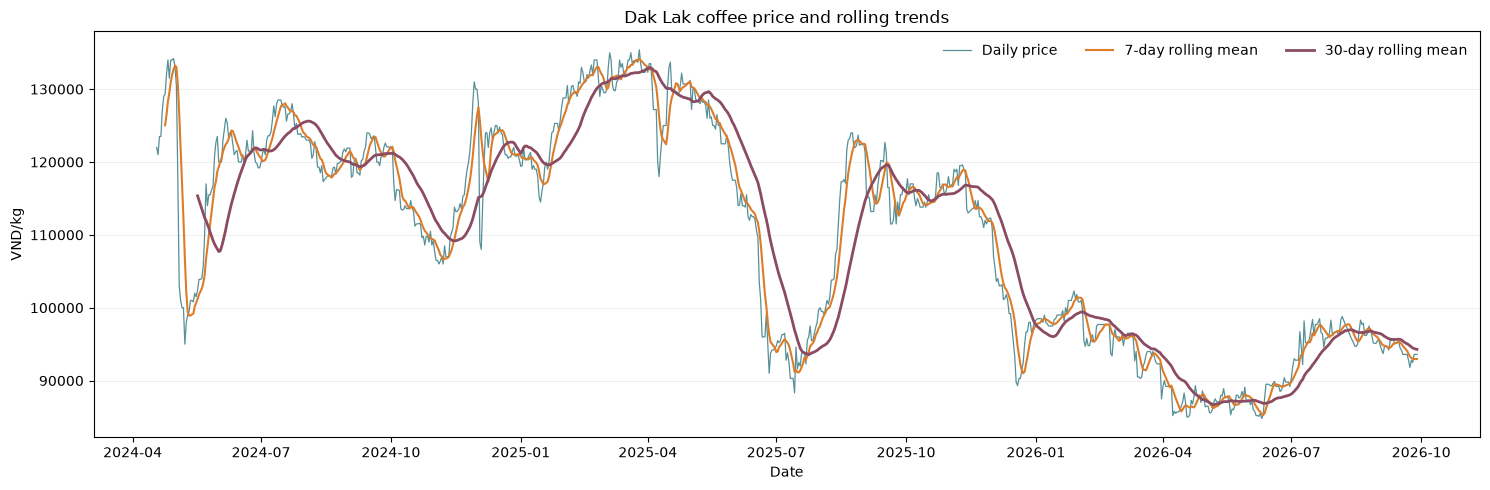

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.date, df[price_col], color="#1f6b75", linewidth=0.9, alpha=0.75, label="Daily price")
ax.plot(df.date, df[price_col].rolling(7).mean(), color="#dc7c28", linewidth=1.5, label="7-day rolling mean")
ax.plot(df.date, df[price_col].rolling(30).mean(), color="#8b4b62", linewidth=2, label="30-day rolling mean")
ax.set(title="Dak Lak coffee price and rolling trends", xlabel="Date", ylabel="VND/kg")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## 3. Phân phối và outlier review

Histogram cho biết phân phối giá; boxplot và quy tắc IQR giúp khoanh vùng điểm cực đoan. Giá cà phê có thể có cú sốc thị trường thật, vì vậy outlier phải được đối chiếu nguồn trước khi quyết định xử lý.

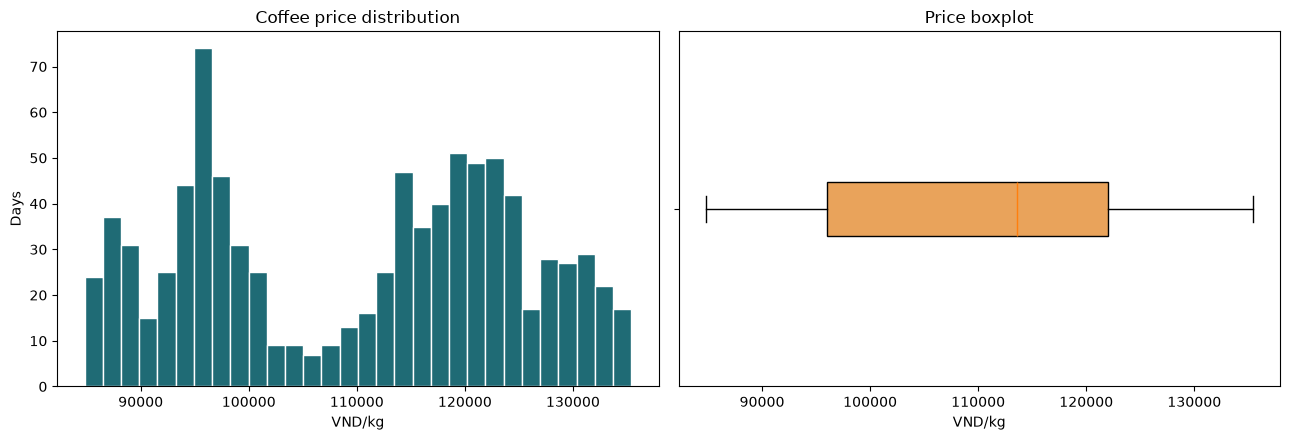

IQR fences: 57,000 to 161,000 VND/kg
Flagged points: 0; these are flagged for review, not removed.


,date,coffee_price


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df[price_col], bins=30, color="#1f6b75", edgecolor="white")
axes[0].set(title="Coffee price distribution", xlabel="VND/kg", ylabel="Days")
axes[1].boxplot(df[price_col], orientation="horizontal", patch_artist=True,
                boxprops={"facecolor": "#e9a35b"})
axes[1].set(title="Price boxplot", xlabel="VND/kg", yticklabels=[])
plt.tight_layout()
plt.show()

q1, q3 = df[price_col].quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df.loc[(df[price_col] < low_fence) | (df[price_col] > high_fence), ["date", price_col]].copy()
print(f"IQR fences: {low_fence:,.0f} to {high_fence:,.0f} VND/kg")
print(f"Flagged points: {len(outliers)}; these are flagged for review, not removed.")
display(outliers.head(20))

## 4. Mùa vụ theo tháng và năm

So sánh phân phối giữa các tháng để tìm dấu hiệu mùa vụ; biểu đồ theo năm cho thấy thay đổi mức giá dài hạn. Dữ liệu mới có khoảng vài năm nên mùa vụ chỉ là dấu hiệu ban đầu, chưa đủ để khẳng định chu kỳ ổn định.

,mean,median,std,count
month,,,,
1,110135.5,108400.0,11322.2,62
2,113864.3,114500.0,17360.4,56
3,113119.4,113000.0,19757.1,62
4,111734.2,123500.0,20759.6,73
5,107222.6,103900.0,16984.1,93
6,105474.4,112000.0,14854.6,90
7,105063.4,96500.0,14554.3,93
8,109839.8,117100.0,11458.8,93
9,110870.5,115500.0,11854.6,88


,mean,median,min,max,count
year,,,,,
2024,118722.1,120600.0,95000,134200,258
2025,116375.1,117300.0,88300,135400,365
2026,93164.9,94500.0,84800,102300,271


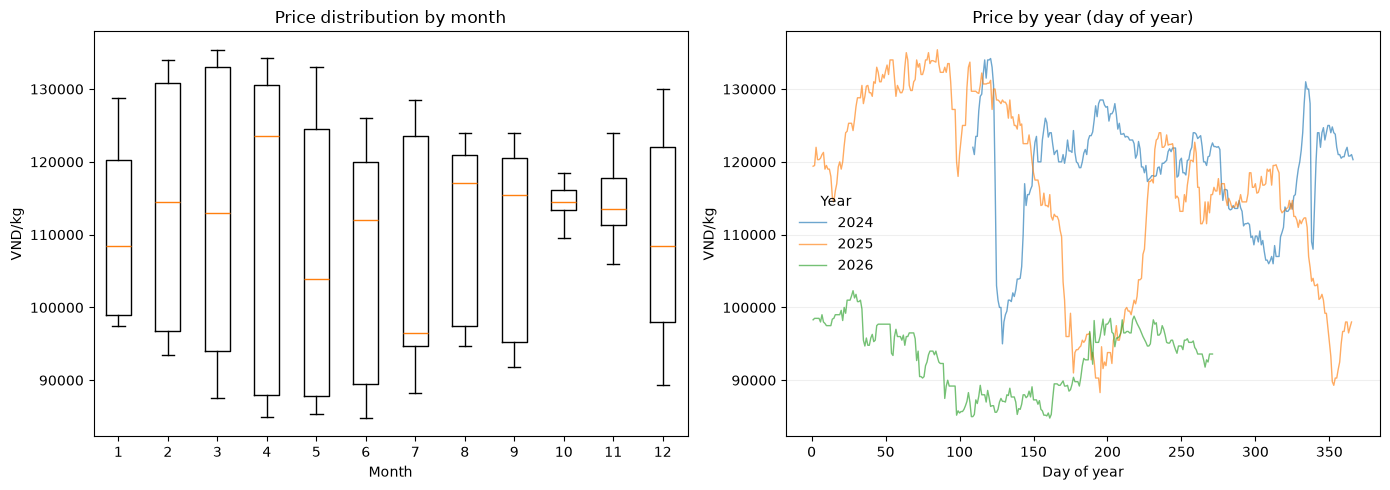

Lowest mean-price month: 7
Highest mean-price month: 11


In [14]:
df["month"] = df.date.dt.month
df["year"] = df.date.dt.year
monthly_price = df.groupby("month")[price_col].agg(["mean", "median", "std", "count"])
yearly_price = df.groupby("year")[price_col].agg(["mean", "median", "min", "max", "count"])
display(monthly_price.round(1))
display(yearly_price.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_data = [df.loc[df.month == month, price_col].to_numpy() for month in range(1, 13)]
axes[0].boxplot(month_data, tick_labels=[str(month) for month in range(1, 13)], showfliers=False)
axes[0].set(title="Price distribution by month", xlabel="Month", ylabel="VND/kg")
for year, group in df.groupby("year"):
    axes[1].plot(group.date.dt.dayofyear, group[price_col], alpha=0.65, linewidth=1, label=str(year))
axes[1].set(title="Price by year (day of year)", xlabel="Day of year", ylabel="VND/kg")
axes[1].legend(title="Year", frameon=False)
axes[1].grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()
print("Lowest mean-price month:", int(monthly_price["mean"].idxmin()))
print("Highest mean-price month:", int(monthly_price["mean"].idxmax()))

## 5. Độ biến động theo thời gian

Thay đổi giá tuyệt đối cho biết các cú tăng/giảm từng ngày; rolling standard deviation 30 ngày cho biết mức biến động nền trong một khoảng dài hơn.

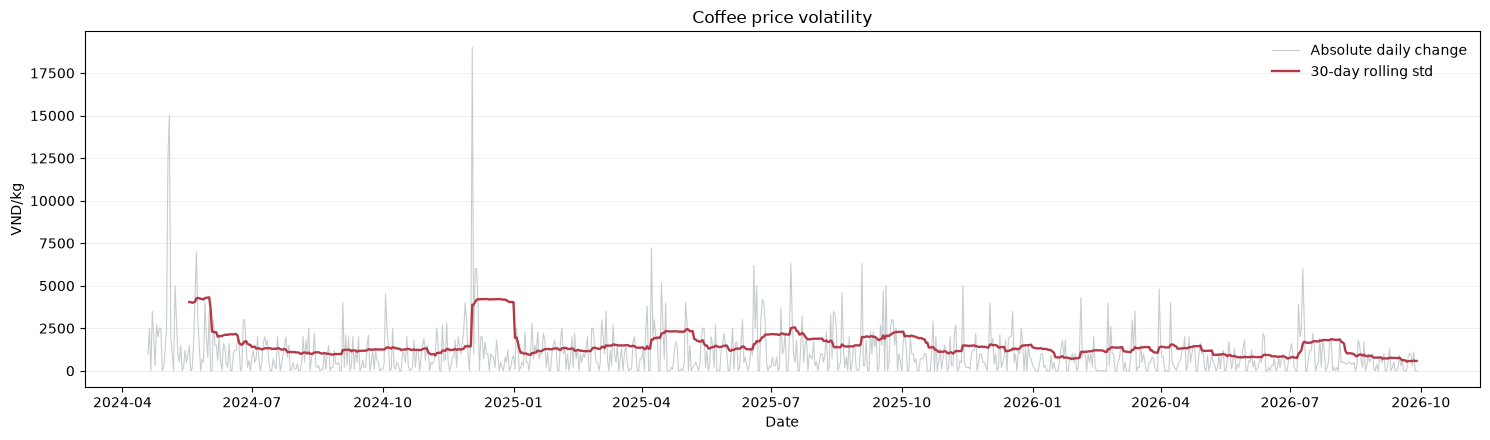

,date,coffee_price,daily_change,absolute_change
229,2024-12-03,109000,-19000.0,19000.0
16,2024-05-04,103000,-15000.0,15000.0
15,2024-05-03,118000,-12500.0,12500.0
355,2025-04-08,120000,-7200.0,7200.0
35,2024-05-23,117000,7000.0,7000.0
453,2025-07-15,94600,6300.0,6300.0
503,2025-09-03,115000,-6300.0,6300.0
427,2025-06-19,103500,-6200.0,6200.0
231,2024-12-05,114000,6000.0,6000.0
232,2024-12-06,120000,6000.0,6000.0


In [15]:
df["daily_change"] = df[price_col].diff()
df["rolling_volatility_30d"] = df.daily_change.rolling(30).std()
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(df.date, df.daily_change.abs(), color="#9aa4a8", linewidth=0.8, alpha=0.55, label="Absolute daily change")
ax.plot(df.date, df.rolling_volatility_30d, color="#b23a48", linewidth=1.7, label="30-day rolling std")
ax.set(title="Coffee price volatility", xlabel="Date", ylabel="VND/kg")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()
display(df.loc[df.daily_change.abs().nlargest(10).index, ["date", price_col, "daily_change"]].assign(
    absolute_change=lambda x: x.daily_change.abs()
).sort_values("absolute_change", ascending=False))

## 6. Missing values và tương quan

Missingness cần kiểm tra vì model không tự hiểu ô trống. Heatmap dùng Pearson correlation để xem quan hệ tuyến tính và feature có tương quan cao; tương quan không đồng nghĩa quan hệ nhân quả.

,missing_percent
date,0.0
coffee_price,0.0
temperature_2m_max,0.0
temperature_2m_min,0.0
temperature_2m_mean,0.0
precipitation_sum,0.0
rain_sum,0.0
precipitation_hours,0.0
relative_humidity_2m_mean,0.0
soil_moisture_0_to_7cm,0.0


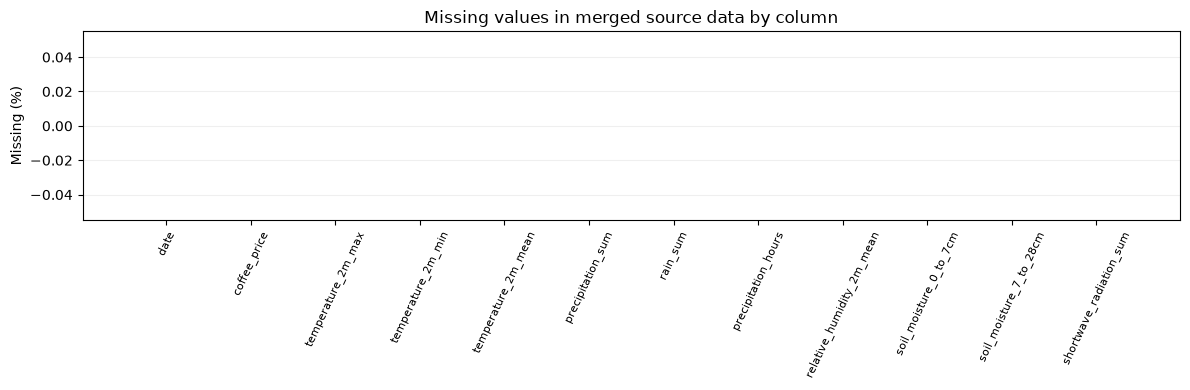

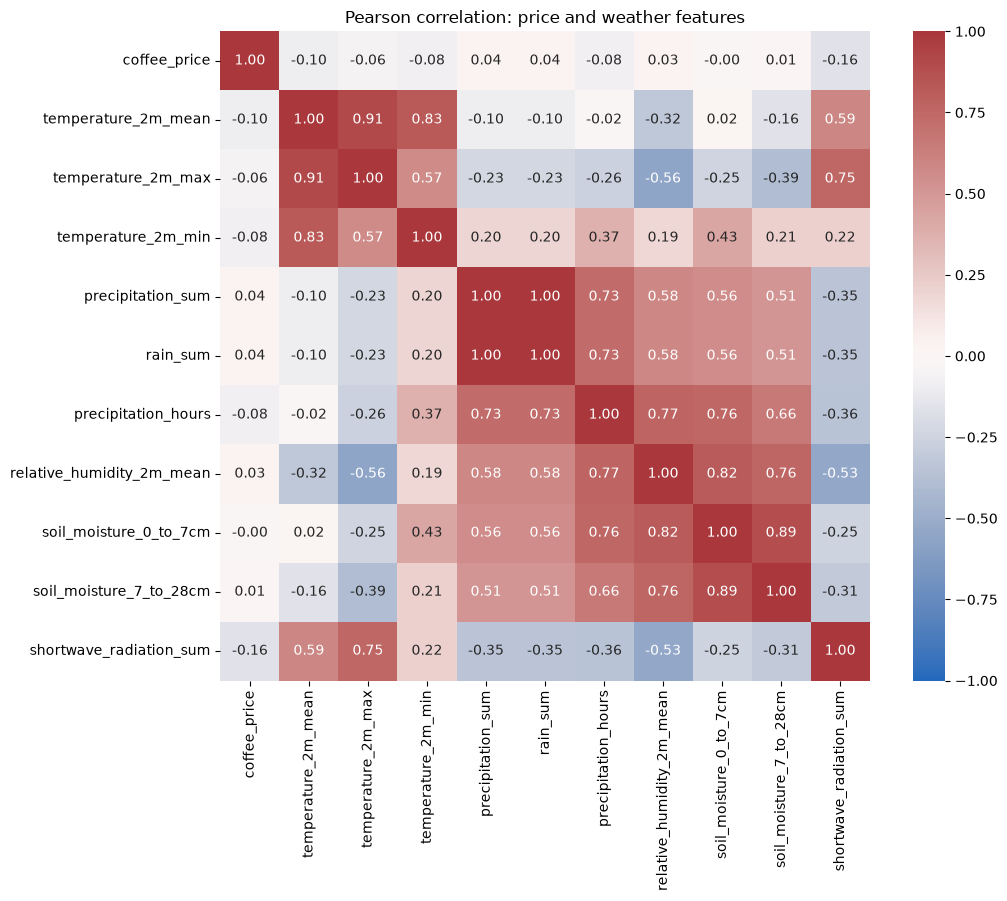

,pearson_r_with_price
shortwave_radiation_sum,-0.157
temperature_2m_mean,-0.099
temperature_2m_min,-0.083
precipitation_hours,-0.079
temperature_2m_max,-0.058
precipitation_sum,0.039
rain_sum,0.039
relative_humidity_2m_mean,0.032
soil_moisture_7_to_28cm,0.011
soil_moisture_0_to_7cm,-0.001


In [16]:
# Đọc lại merged gốc để không tính NaN warm-up do rolling features ở cell volatility.
source_data = pd.read_csv(DATA_PATH, parse_dates=["date"])
missing_pct = (source_data.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.rename("missing_percent").to_frame().round(2))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(missing_pct.index, missing_pct.values, color="#4c956c")
ax.set(title="Missing values in merged source data by column", ylabel="Missing (%)")
ax.tick_params(axis="x", rotation=65, labelsize=8)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

corr_cols = [price_col, *[col for col in weather_cols if col in source_data.columns]]
corr = source_data[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Pearson correlation: price and weather features")
plt.tight_layout()
plt.show()
price_correlations = corr[price_col].drop(price_col).sort_values(key=lambda values: values.abs(), ascending=False)
display(price_correlations.rename("pearson_r_with_price").to_frame().round(3))

In [17]:
# So sánh weather ở ngày T với target ngày T+1, ngoài tương quan cùng ngày.
next_day_price = df[price_col].shift(-1)
weather_next_day_corr = df[weather_cols].corrwith(next_day_price).sort_values(
    key=lambda values: values.abs(), ascending=False
)
weather_pair_corr = df[weather_cols].corr()
redundant_pairs = [
    (left, right, float(weather_pair_corr.loc[left, right]))
    for index, left in enumerate(weather_cols)
    for right in weather_cols[index + 1:]
    if abs(weather_pair_corr.loc[left, right]) >= 0.95
]
print("Weather at T vs coffee price at T+1 (Pearson):")
display(weather_next_day_corr.rename("pearson_r").to_frame().round(3))
print("Weather feature pairs with |correlation| >= 0.95:")
print(redundant_pairs if redundant_pairs else "None")
print("rain_sum equals precipitation_sum on every row:", bool((df["rain_sum"] == df["precipitation_sum"]).all()))

Weather at T vs coffee price at T+1 (Pearson):


,pearson_r
shortwave_radiation_sum,-0.153
temperature_2m_mean,-0.099
temperature_2m_min,-0.084
precipitation_hours,-0.080
temperature_2m_max,-0.058
precipitation_sum,0.038
rain_sum,0.038
relative_humidity_2m_mean,0.031
soil_moisture_7_to_28cm,0.010
soil_moisture_0_to_7cm,-0.003


Weather feature pairs with |correlation| >= 0.95:
[('precipitation_sum', 'rain_sum', 1.0)]
rain_sum equals precipitation_sum on every row: True


### Diễn giải kết quả tương quan

Pearson `r` chỉ đo quan hệ **tuyến tính từng cặp**: gần `0` nghĩa là không thấy quan hệ tuyến tính rõ trong mẫu này, không có nghĩa feature chắc chắn vô dụng. Quan hệ có thể phi tuyến, có độ trễ nhiều ngày, hoặc bị che bởi xu hướng giá và yếu tố thị trường quốc tế.

Trong dữ liệu hiện tại, weather liên hệ tuyến tính với giá ở mức yếu đến yếu-vừa: humidity có r khoảng `0.257`, soil moisture lớp 7-28 cm `0.241`, bức xạ `-0.233`, còn nhiệt độ min gần như `0` (`-0.003`). Với giá ngày kế tiếp, các hệ số cũng tương tự: cao nhất là humidity `0.251`; nhiệt độ min `-0.002`. Do đó EDA **chưa cho thấy weather đơn lẻ dự báo giá mạnh**, nhưng cũng chưa đủ căn cứ để kết luận không có ích.

Một trường hợp khác với tương quan yếu là hai feature trùng lặp: `rain_sum` và `precipitation_sum` giống hệt nhau trên toàn bộ 975 ngày (r = `1.0`). Chúng không bổ sung thông tin cho nhau. Notebook giữ cả hai để bám schema nguồn ban đầu; khi chọn model feature, nên thử ablation chỉ giữ một cột và so sánh validation theo thời gian. Với Linear Regression, trùng lặp có thể gây đa cộng tuyến; tree models thường ít nhạy hơn nhưng vẫn không nhận thêm tín hiệu.

Vì vậy không nên bỏ feature chỉ do một hệ số thấp. Quyết định cuối cùng cần dựa trên so sánh cùng một chronological validation: giá + lịch so với giá + lịch + weather, và kiểm tra thêm weather rolling/lagged. Nếu metric ngoài mẫu không cải thiện ổn định so với price-only thì dữ liệu hiện tại chưa chứng minh weather giúp ích.

## 7. Weather so với giá cà phê

Scatter plot giúp nhìn dạng quan hệ, cụm và outlier cho từng biến. Đây là quan hệ cùng ngày trong tập lịch sử, không chứng minh thời tiết làm thay đổi giá; giá còn chịu ảnh hưởng của cung-cầu, tỷ giá và thị trường quốc tế.

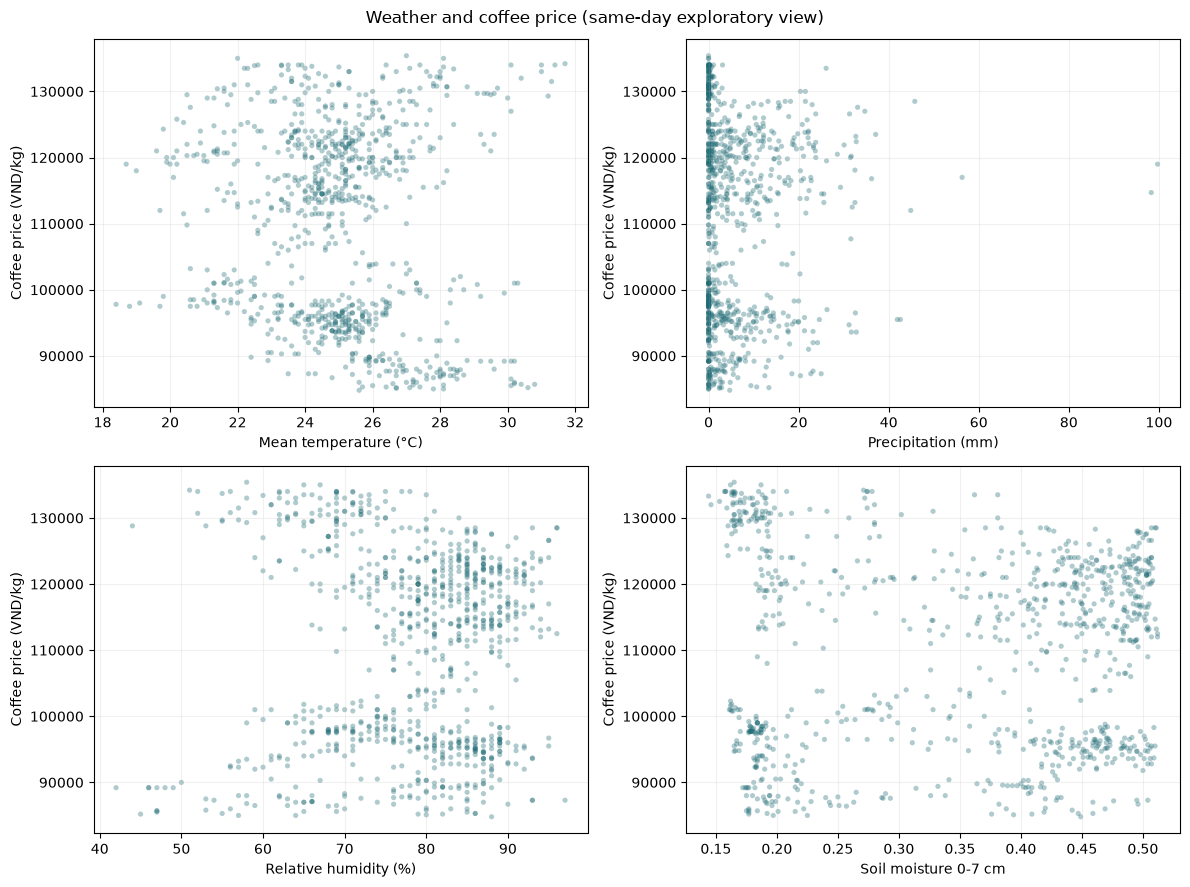

In [18]:
scatter_pairs = [
    ("temperature_2m_mean", "Mean temperature (°C)"),
    ("precipitation_sum", "Precipitation (mm)"),
    ("relative_humidity_2m_mean", "Relative humidity (%)"),
    ("soil_moisture_0_to_7cm", "Soil moisture 0-7 cm"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (column, label) in zip(axes.flat, scatter_pairs):
    ax.scatter(df[column], df[price_col], s=14, alpha=0.35, color="#1f6b75", edgecolors="none")
    ax.set(xlabel=label, ylabel="Coffee price (VND/kg)")
    ax.grid(alpha=0.18)
fig.suptitle("Weather and coffee price (same-day exploratory view)")
plt.tight_layout()
plt.show()

## 8. Vì sao chọn các feature này, và vì sao không đưa tất cả feature khác?

Feature được chọn theo thời điểm dự đoán: tại ngày `T`, ta biết giá và thời tiết đã quan sát đến `T`, rồi dự đoán giá `T+1`. Một feature chỉ nên dùng nếu nó có thể thực sự biết được ở thời điểm dự đoán, có ý nghĩa nghiệp vụ, và không mã hóa target tương lai.

| Nhóm | Feature được giữ | Vì sao hữu ích | Hạn chế cần nhớ |
|---|---|---|---|
| Giá hiện tại | `coffee_price` | Là giá quan sát mới nhất và mốc tham chiếu tự nhiên khi dự đoán ngày kế tiếp. | Cần đúng thời điểm phát hành giá; không dùng giá của `T+1`. |
| Lag giá | `price_lag_1/2/3/7/14/30` | Đại diện quán tính ngắn hạn, nhịp tuần và mức tham chiếu tháng. | Các lag tương quan mạnh; nhiều lag hơn không mặc định tốt hơn. |
| Rolling giá | `price_mean_7/14/30`, `price_std_7/30` | Mean làm mượt nhiễu; std biểu diễn mức biến động gần đây. | Phải tính trên quá khứ. Pipeline dùng `shift(1)` trước rolling để không nhìn target. |
| Nhiệt độ | mean/max/min | Bao quát mức nền và hai cực trị ngày, có ý nghĩa đối với sinh trưởng/thu hoạch. | Tương quan cao với nhau; giữ trong MVP để so sánh, nhưng nên ablation/regularize cho Linear Regression. |
| Mưa | `precipitation_sum`, `rain_sum`, `precipitation_hours` | Lượng và thời lượng mưa diễn tả điều kiện mùa vụ khác nhau; precipitation bao gồm tổng giáng thủy, rain là phần mưa lỏng. | Có thể gần trùng nhau ở khí hậu địa phương; kiểm tra tương quan và thử bỏ từng biến. |
| Ẩm/đất | humidity mean, soil moisture 0-7cm và 7-28cm | Độ ẩm không khí và các lớp đất đại diện điều kiện nước khác nhau. | Có thể phản ứng chậm, tương quan với mưa; không diễn giải importance thành quan hệ nhân quả. |
| Bức xạ | `shortwave_radiation_sum` | Đại diện năng lượng mặt trời trong ngày, bổ sung tín hiệu không đo được chỉ bằng nhiệt độ/mưa. | Có thể tương quan với nhiệt độ và mùa. |
| Rolling thời tiết | mưa, nhiệt độ mean, humidity mean trong 7/30 ngày | Nông nghiệp chịu ảnh hưởng tích lũy, không chỉ thời tiết một ngày. | Cũng phải `shift(1)` để chỉ dùng dữ liệu đã biết trước dự báo. |
| Lịch | weekday, day-of-month, month, quarter, sin/cos month | Mã hóa lịch công bố giá và mùa vụ; sin/cos giữ tính chu kỳ khi tháng 12 gần tháng 1. | Các biến tháng/quarter/sin-cos chồng lấp; dùng số lượng vừa phải và xác nhận bằng validation. |

### Không đưa vào feature hiện tại

- `next_day_price`: đây là **target**, tuyệt đối không được đưa vào `X`.
- `date_gap_days`: được tính từ ngày hiện tại tới ngày kế tiếp; là thông tin tương lai và chỉ dùng kiểm tra chất lượng chuỗi.
- `date`, `province`, `product`, `unit`, `source`, `source_url`: cột thời gian thô/định danh hoặc metadata. Lịch đã được mã hóa thành calendar features; tỉnh/sản phẩm/đơn vị hiện gần như hằng số nên không giúp model học quy luật.
- `price_change`: chưa đưa vào MVP vì thường được suy ra từ chênh lệch giá và có thể trùng với lag/current price; cần xác minh đúng định nghĩa và thời điểm nguồn công bố trước khi dùng.
- Gió, ET0, soil temperature và biến khác: không có trong schema weather hiện tại hoặc nằm ngoài nhóm đã chọn cho MVP; không tạo dữ liệu giả để lấp vào.
- Giá Robusta quốc tế, USD/VND: là feature thị trường đáng thử ở experiment riêng khi có nguồn dữ liệu được lưu provenance.

### Khi nào thời tiết gây leakage?

Weather của ngày `T` chỉ dùng để dự đoán `T+1` nếu dự báo được tạo **sau khi dữ liệu daily của T đã hoàn tất và có sẵn**. Nếu dự báo được tạo trước khi ngày T kết thúc, không được dùng weather thực đo cả ngày T; khi đó cần dùng weather forecast tại thời điểm phát hành dự báo hoặc lùi weather features lại. Các rolling weather features phải lấy từ ngày trước đó, giống cách pipeline hiện tại xử lý.

### Cách quyết định giữ/bỏ bằng thí nghiệm

Không chọn feature chỉ vì tương quan cao hoặc vì model cho feature importance lớn. So sánh ít nhất hai thí nghiệm trên cùng chronological split/walk-forward validation: (1) giá + lịch, (2) giá + lịch + thời tiết. Chỉ giữ weather nếu lỗi ngoài mẫu cải thiện ổn định so với price-only; nếu không, báo cáo rằng dữ liệu hiện tại chưa chứng minh thời tiết giúp dự đoán.